### Calculation of the dressed interaction 

In [1]:
using LinearAlgebra
using Printf
using PyPlot

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=14, titlesize=14)
rc("legend", fontsize=10)


In [182]:
# -----------------------------
# Physical and numerical parameters
# Defaults are for notebook/smoke tests. Increase L, NΩ, and Nω for production runs.
# -----------------------------
L    = 100#36                     # momentum points; increase for production
γ_c  = 1.0                       # intralayer hopping
γ_v1 = 1.0
γ_v2 =1.0

Δ_0 = 2.2                  # Gap from v1 to c associates with the exciton A (Chemical potential is in zero) 
δ_v1v2 = 1.0                  # Distance from v1 to v2
Mmag = 1.0                    # magnitude of the classical magnetizations
θ = π/4                       # fixed angle between M1 and M2

Jpd_A = -0.6 #0.1                    # p-d coupling (introduces the pd hibridization that generates magnetism)
Jpd_B = -0.3
V_A = -0.5                       # Effective excitonic attraction of exciton A
V_B = -0.5                       # Effective excitonic attraction of exciton B

### Thermodynamicall parameters 
T = 0.08                      # electronic temperature
μchem = 0.0                   # common chemical potential (The system is formulated around zero but it can be displaced)
ηe = 0.08                     # electronic Green-function broadening
ηΩ = 2ηe                      # effective broadening of the band benchmark


### Energy sscales
Ωmin, Ωmax, NΩ = -10.0, 25.0, 401 # Evaluation of energy 
ωmin, ωmax, Nω = -25.0, 25.0, 601 # Integration energy
ks = collect(range(-π, stop=π - 2π/L, length=L)) # momentum evaluation 
Ωs = collect(range(Ωmin, Ωmax, length=NΩ))
ωs = collect(range(ωmin, ωmax, length=Nω))
dω = ωs[2] - ωs[1]; ### dω of integration energy 

In [183]:
# Pauli matrices in physical spin space.
σ_spin_0 = ComplexF64[1 0; 0 1]
σ_spin_x = ComplexF64[0 1; 1 0]
σ_spin_y = ComplexF64[0 -1im; 1im 0]
σ_spin_z = ComplexF64[1 0; 0 -1]
# In the future Gell-Man matrices maybe shoulb be needed to 
# to describe exciton parameters 

2×2 Matrix{ComplexF64}:
 1.0+0.0im   0.0+0.0im
 0.0+0.0im  -1.0+0.0im

In [184]:
#Some building-blocks functions 
ϵk(k, γ) = -2γ*cos(k) # Depending on the coupling itr describes different energies

function h(k,θ; l::Int )
    ## Note that we can choose the chemicaal potential to be always around zero or any other point 
    ## with reference to v1, but because it enters in the fermi function here the cero is the minimum
    #ε_v1 = ϵk(k,γ_v1) + Jpd_A*cos(θ/2) 
    # ε_v2 = ϵk(k,γ_v2) + δ_v1v2  + Jpd_B*cos(θ/2)
    # ε_c = -ϵk(k,γ_c) + Δ_0 + 4*γ_c
    #ε = ϵk(k,γ_v1)
    (l == 1) && (ε = -ϵk(k,γ_v1) - 2γ_v1  )
     (l == 2) && (ε = -ϵk(k,γ_v2)- 2γ_v1 - δ_v1v2  - Jpd_B*cos(θ/2)  + Jpd_A*cos(θ/2)  )
     (l == 3) && (ε = ϵk(k,γ_c) + Δ_0  + 2γ_v1 + Jpd_A*cos(θ/2)  )
    return ε
end


function fermi(E; T=T, μ=0.0) ### We assume that chemical potential enters in the fermi function 
    x = (E - μ) / T
    x > 60 && return 0.0
    x < -60 && return 1.0
    return 1 / (exp(x) + 1)
end


fermi (generic function with 1 method)

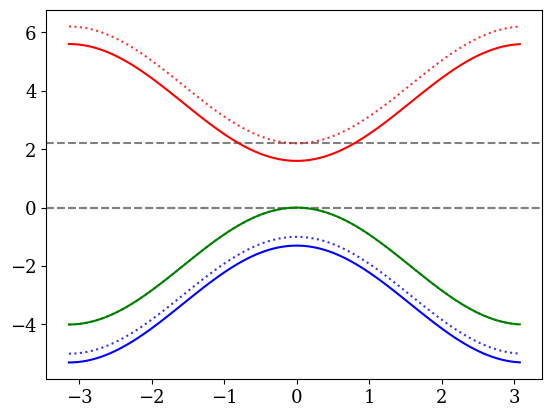

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f04731a3530>

In [185]:
#h(0.0,0.0; l=1 )



ϵ1_θ1(k) = h(k,0.0; l=1)
ϵ2_θ1(k) = h(k,0.0; l=2)
ϵ3_θ1(k) = h(k,0.0; l=3 )
ϵ1_θ2(k) = h(k,pi; l=1)
ϵ2_θ2(k) = h(k,pi; l=2)
ϵ3_θ2(k) = h(k,pi; l=3 )

plt.axhline(0.0, color = "gray",ls = "--")
plt.axhline(Δ_0, color = "gray",ls = "--")


plt.axhline(0.0, color = "gray",ls = "--")
plt.plot(ks,ϵ1_θ1.(ks),color= "green")
plt.plot(ks,ϵ2_θ1.(ks),color= "blue")
plt.plot(ks,ϵ3_θ1.(ks),color= "red")


plt.plot(ks,ϵ1_θ2.(ks),color= "green",alpha = 0.8,ls = ":")
plt.plot(ks,ϵ2_θ2.(ks),color= "blue",alpha = 0.8,ls = ":")
plt.plot(ks,ϵ3_θ2.(ks),color= "red",alpha = 0.8,ls = ":")

## Figure 1: bare electron-hole continuum

Before looking at the excitonic propagator, we plot the bare transition energies

$$\Delta E_{ab}(k)=E^1_a(k)-E^2_b(k).$$

The lower edge of this continuum is the reference for identifying bound excitonic modes.


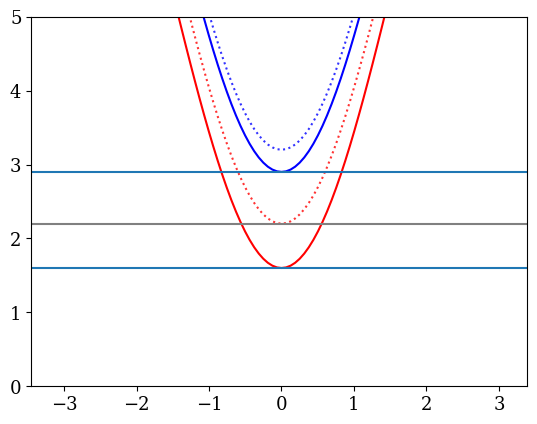

(0.0, 5.0)

In [186]:
ΔEb_A(k) = h(k,0.0; l=3) -  h(k,0.0; l=1)
ΔEb_B(k) = h(k,0.0; l=3) -  h(k,0.0; l=2)

ΔEb_A2(k) = h(k,pi; l=3) -  h(k,pi; l=1)
ΔEb_B2(k) = h(k,pi; l=3) -  h(k,pi; l=2)

plt.plot(ks, ΔEb_A.(ks),color="red")
plt.plot(ks, ΔEb_B.(ks),color="blue")

plt.plot(ks, ΔEb_A2.(ks),color="red",alpha=0.8,ls = ":")
plt.plot(ks, ΔEb_B2.(ks),color="blue",alpha=0.8,ls = ":")

plt.axhline(Δ_0,color="gray")
#plt.axhline(Δ_0 + δ_v1v2,color="gray")


plt.axhline(Δ_0 + Jpd_A*cos(0.0))
plt.axhline(Δ_0 + Jpd_B*cos(0.0) + δ_v1v2)

# Eb_A = Δ_0 + Jpd_A*cos(θ/2)

# Eb_B = Δ_0 + Jpd_B*cos(θ/2)

plt.ylim(0,5)
# ϵ1_θ1(k) = h(k,0.0; l=1)
# ϵ2_θ1(k) = h(k,0.0; l=2)

0.4047619047619047

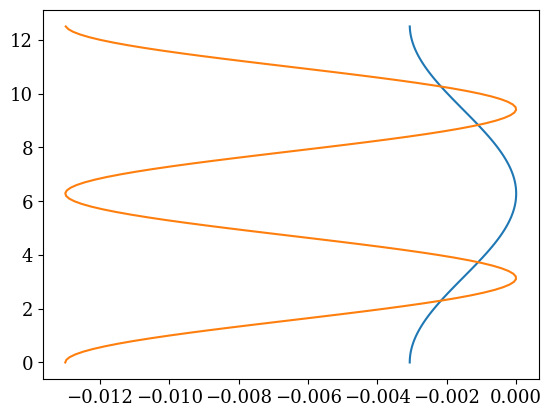

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f046c73f050>

In [451]:
## analitical exciton energy 
Δ_0 = 2.1 



# γ_c  = .45                      
# γ_v1 = .3
# γ_v2 = .25


δ_v1v2 = -0.215# -0.5
Jpd_A = -0.004 # -0.5
Jpd_B = -0.04  # -0.5
V_A = -0.895   # -0.5
V_B = -0.845   # -0.5

##--->1.65 y 1.01 U
##--->0.12 th
##--->0.4  δ
##--->
# plt.axvline(1.35)
# plt.axvline(1.68)
#1.73 
#1.37




Eb_A(θ) =  Δ_0 + Jpd_A*cos(θ/2)# 
Eb_B(θ) = Δ_0 + Jpd_B*cos(θ/2) - δ_v1v2



Ex_A(θ) =   Eb_A(θ) + Eb_A(θ)/(Eb_A(θ)+V_A)
#Ex_A2(θ) =    #Eb_A(θ)
#  #Eb_A(θ)
Ex_B(θ) = Eb_B(θ) + Eb_B(θ)/(Eb_B(θ)+V_B)


θs = collect(0.0:0.1:4pi)

plt.plot(Ex_A.(θs) .- Ex_A(2pi) ,θs)
plt.plot(-0.013cos.(θs/2).^2 ,θs)


#plt.plot(-0.0065(cos.(θs/2) .+1 ) ,θs)
#plt.plot(Ex_A2.(θs),θs)

#plt.xlim(1.34,1.37)
# plt.plot(-0.01*(cos.(θs/4).^2 .-0.5) .+1.356,θs)
# plt.plot(-0.005*(cos.(θs/2) .-0.5) .+1.3534,θs)
#plt.xlim(1.64, 1.8)

#plt.plot(Ex_B.(θs),θs)

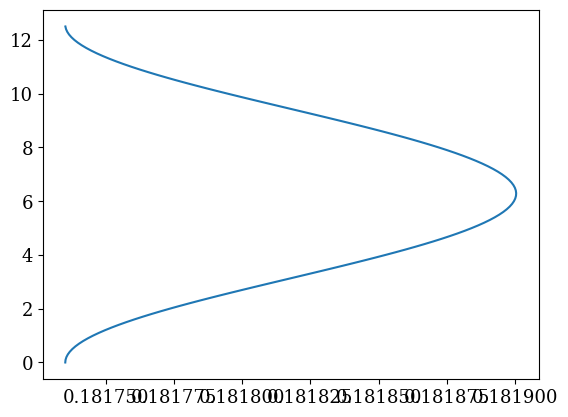

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f046b6a9ee0>

In [493]:

Δ_0 = 2


Jpd_A = -0.01 # -0.5
#Jpd_B = -0.04  # -0.5
V_A = 0.2#-1.8   # -0.5


Eb_A(θ) =  Δ_0 + Jpd_A*cos(θ/2)# 
Ex_A(θ) =  Eb_A(θ)*V_A/(Eb_A(θ)+V_A)
plt.plot(Ex_A.(θs) , θs )

In [ ]:
### square depende



In [424]:
0.04^2

0.0016

In [425]:
0.004^2

1.6e-5

In [426]:
0.0065

0.0065

In [326]:
2.07 -0.7

1.3699999999999999

In [328]:
2.03-0.3

1.7299999999999998